## Butterworth filter examples

Demonstrates:
- designing Butterworth low/high/band-pass filters
- plotting frequency response
- filtering a noisy signal with zero-phase filtering (filtfilt)

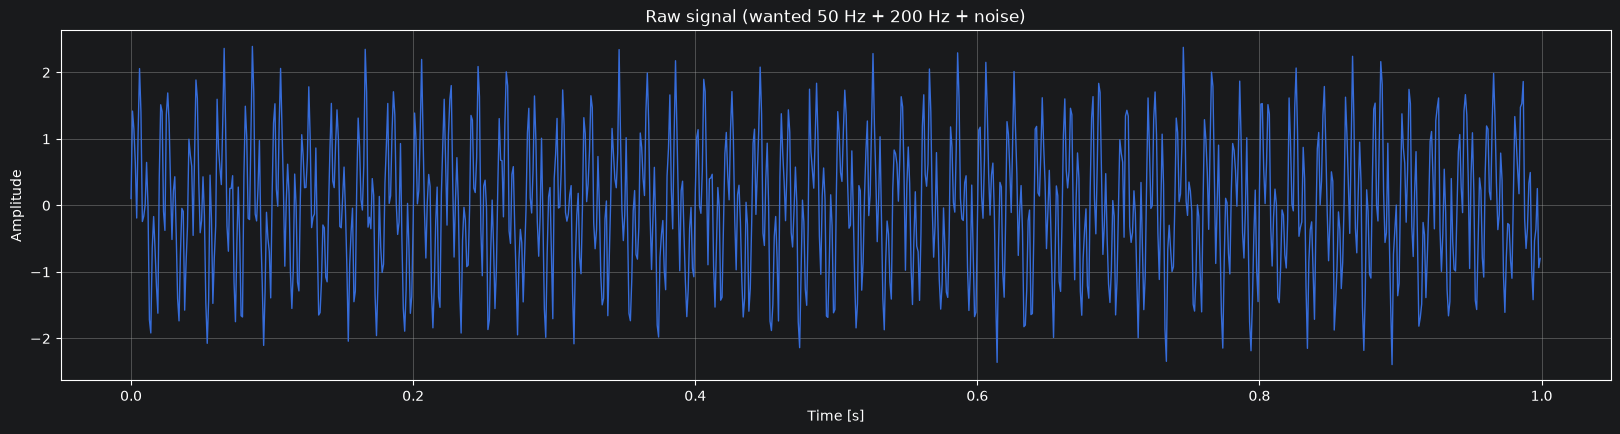

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from engine import synth, white_noise

# Sampling settings
fs = 1000.0  # Hz
t = np.arange(0, 1.0, 1.0 / fs)  # 1 second

# Create example signal: 50 Hz sine (wanted) + 200 Hz sine (noise) + white noise
sig_wanted = synth(50, 1, 1, fs, "sine")
sig_noise_tone = synth(200, 1, 1, fs, "sine")
sig_noise = white_noise(1.0, 0.5, fs)
x = sig_wanted + sig_noise_tone + sig_noise

plt.figure(figsize=(20, 10))
plt.subplot(2, 1, 1)
# plt.plot(t, sig_wanted, linewidth=1)
# plt.plot(t, sig_noise_tone, linewidth=1)
# plt.plot(t, sig_noise, linewidth=1)
plt.plot(t, x, linewidth=1)

plt.title("Raw signal (wanted 50 Hz + 200 Hz + noise)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)

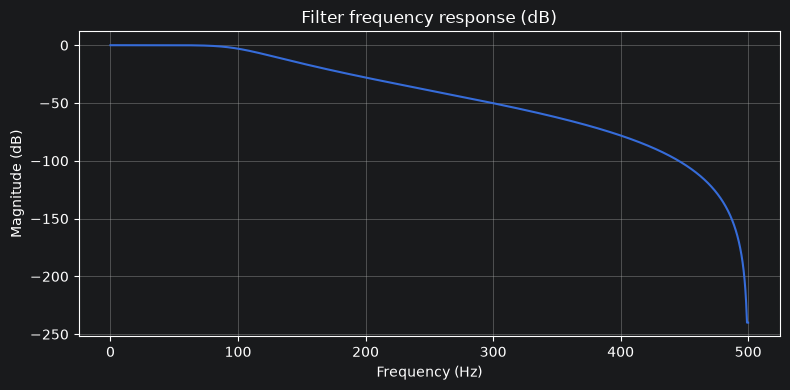

In [2]:
from scipy.signal import freqz

from engine import apply_filter, butter


def plot_freq_response(b, a, fs, ax=None):
    """
    Plot frequency response of filter.
    """
    w, h = freqz(b, a, worN=8000)
    freqs = (w / (2 * np.pi)) * fs
    mag = 20 * np.log10(np.maximum(np.abs(h), 1e-12))  # dB

    if ax is None:
        plt.figure(figsize=(8, 4))
        plt.plot(freqs, mag)
        plt.title("Filter frequency response (dB)")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Magnitude (dB)")
        plt.grid(True)
    else:
        ax.plot(freqs, mag)
        ax.set_title("Filter frequency response (dB)")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Magnitude (dB)")
        ax.grid(True)


# Design a 4th-order lowpass Butterworth with cutoff 100 Hz
order = 4
cutoff = 100.0  # Hz
b, a = butter(order, cutoff, fs, btype="low")

# Frequency response
plot_freq_response(b, a, fs)
plt.tight_layout()
plt.show()

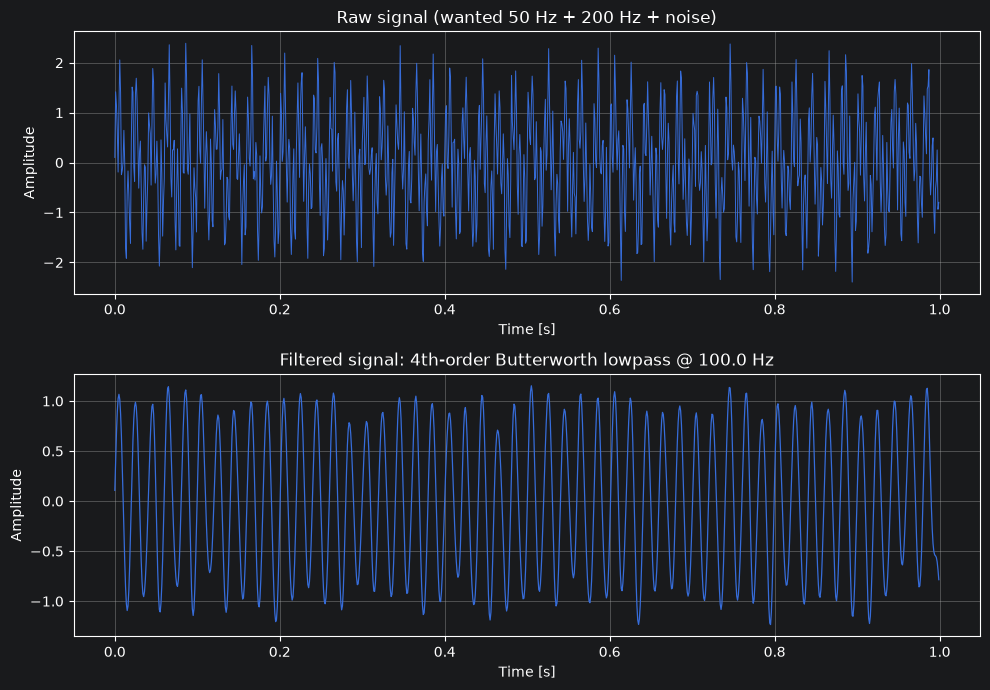

In [3]:
# Filter the signal (zero-phase)
y = apply_filter(b, a, x)

# Plot time-domain comparison
plt.figure(figsize=(10, 7))
plt.subplot(2, 1, 1)
plt.plot(t, x, linewidth=0.7)
plt.title("Raw signal (wanted 50 Hz + 200 Hz + noise)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, y, linewidth=0.9)
plt.title(f"Filtered signal: {order}th-order Butterworth lowpass @ {cutoff} Hz")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

## Bandpass filter example

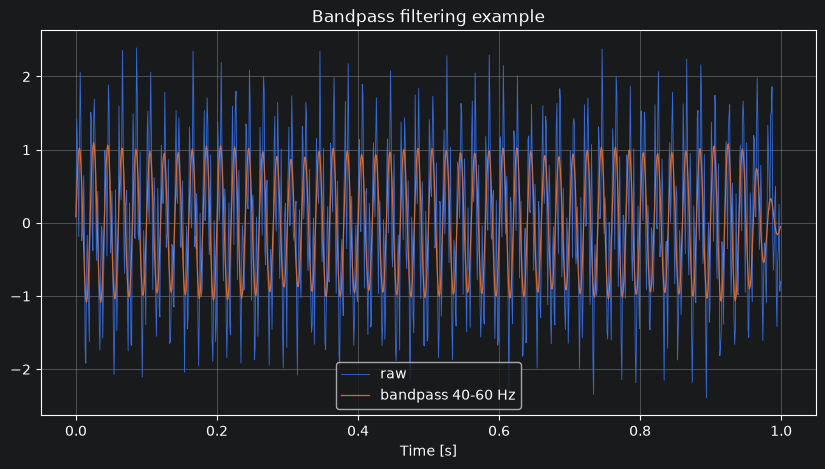

In [4]:
# Example bandpass: keep 40-60 Hz
b_bp, a_bp = butter(4, (40.0, 60.0), fs, btype="band")
y_bp = apply_filter(b_bp, a_bp, x)

plt.figure(figsize=(10, 5))
plt.plot(t, x, label="raw", linewidth=0.6)
plt.plot(t, y_bp, label="bandpass 40-60 Hz", linewidth=0.9)
plt.legend()
plt.title("Bandpass filtering example")
plt.xlabel("Time [s]")
plt.grid(True)
plt.show()

## Filtering sound example

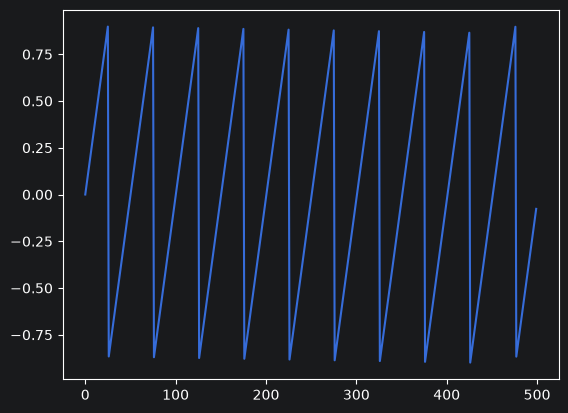

In [5]:
from src.utils import play_wave

sr = 22050

ys = synth(440, 2, 0.9, sr, "saw")
plt.plot(ys[:500])
# play_wave(ys, sr)
plt.show()

Text(0.5, 1.0, '4th-order Butterworth lowpass')

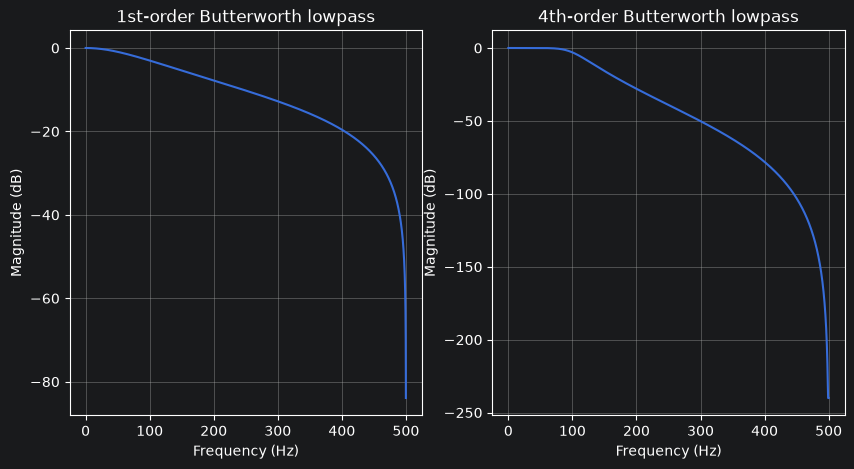

In [6]:
# Low order
b, a = butter(1, 100, fs=fs, btype="low")

# Higher order
b2, a2 = butter(4, 100, fs=fs, btype="low")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

plot_freq_response(b, a, fs, ax[0])
ax[0].set_title("1st-order Butterworth lowpass")

plot_freq_response(b2, a2, fs, ax[1])
ax[1].set_title("4th-order Butterworth lowpass")

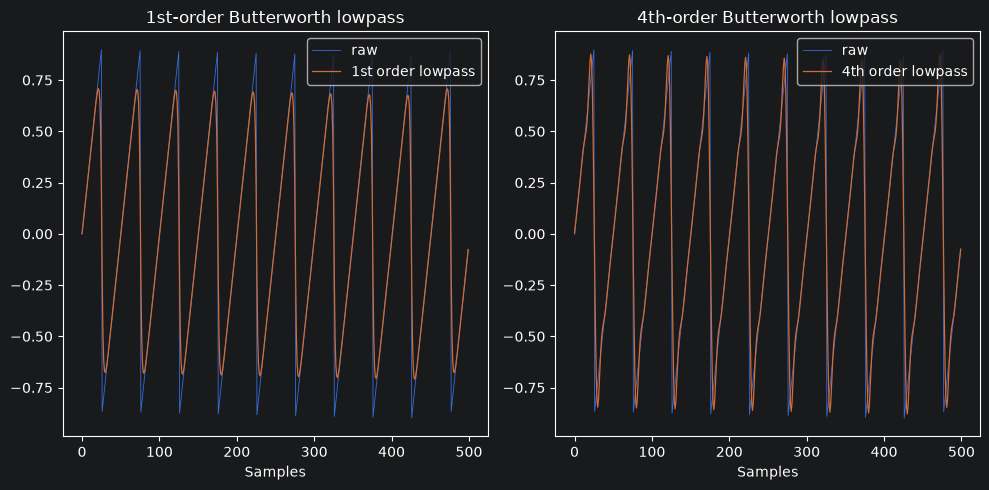

In [7]:
yf = apply_filter(b, a, ys)
yf2 = apply_filter(b2, a2, ys)


fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(ys[:500], label="raw", linewidth=0.6)
ax[0].plot(yf[:500], label="1st order lowpass", linewidth=0.9)
ax[0].legend()
ax[0].set_title("1st-order Butterworth lowpass")
ax[0].set_xlabel("Samples")

ax[1].plot(ys[:500], label="raw", linewidth=0.6)
ax[1].plot(yf2[:500], label="4th order lowpass", linewidth=0.9)
ax[1].legend()
ax[1].set_title("4th-order Butterworth lowpass")
ax[1].set_xlabel("Samples")
plt.tight_layout()
plt.show()

In [10]:
play_wave(ys)
play_wave(yf)
play_wave(yf2)